# Chapter 7 Lab — Forward and Reverse Inference (Python)

Standard brain maps tell us the probability of activation given a psychological state — *forward inference*, or sensitivity. What we usually want is the probability of the state given activation — *reverse inference*, or positive predictive value (PPV). In this lab you will implement Bayes' rule as a reverse-inference calculator, verify it with a Monte Carlo simulation, explore how PPV depends on specificity and base rate, and build a toy "reverse inference map" that shows why forward-inference maps and reverse-inference maps of the same state can look very different.

**How to run this notebook:** it runs in the browser (Pyodide), on [Google Colab](https://colab.research.google.com/github/torwager/elements-of-fmri-tutorials/blob/main/part2/labs/ch07-lab-python.ipynb), or locally — it uses only numpy, pandas, and matplotlib, with simulated data. Companion reading: the [Chapter 7 tutorial page](../ch07-forward-and-reverse-inference.md).

**▶ This notebook is interactive.** Click the **⏻ power icon** at the top right of this page to run it in your browser — no installation needed (the kernel takes ~30–60 s to start the first time). Then run cells **top to bottom**, starting with the first code cell below: later cells depend on the imports and variables defined earlier, and will error if you skip ahead.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(7)
plt.rcParams["figure.dpi"] = 100

## 1. Bayes' rule as a reverse-inference calculator

Forward inference is $P(\text{Brain} \mid \text{Psy})$ — the **sensitivity** of a brain measure to a psychological state. Reverse inference is $P(\text{Psy} \mid \text{Brain})$ — the **PPV**. Bayes' rule connects them:

$$P(\text{Psy} \mid \text{Brain}) = \frac{P(\text{Brain} \mid \text{Psy})\,P(\text{Psy})}{P(\text{Brain})}
= \frac{\text{Sens} \times \text{BR}}{\text{Sens} \times \text{BR} + (1-\text{Spec})(1-\text{BR})}$$

where BR is the **base rate** of the state and Spec is the **specificity**, $P(\sim\text{Brain} \mid \sim\text{Psy})$. Let's implement this and reproduce the chapter's caudate / punishment-motivation example.

In [2]:
def ppv(sens, spec, base_rate):
    """Positive predictive value P(Psy | Brain) via Bayes' rule.

    sens      : P(Brain | Psy)        -- sensitivity (forward inference)
    spec      : P(~Brain | ~Psy)      -- specificity
    base_rate : P(Psy)                -- prior probability of the state
    """
    sens, spec, br = np.asarray(sens), np.asarray(spec), np.asarray(base_rate)
    return sens * br / (sens * br + (1 - spec) * (1 - br))


# The chapter's toy example: caudate activation and punishment motivation
scenarios = pd.DataFrame(
    [
        ["Chapter example",            0.90, 0.80, 0.10],
        ["Perfect sensitivity",        1.00, 0.80, 0.10],
        ["Rare state (1% base rate)",  0.90, 0.80, 0.01],
        ["Highly specific region",     0.90, 0.99, 0.10],
        ["Specific AND common state",  0.90, 0.99, 0.50],
    ],
    columns=["scenario", "sensitivity", "specificity", "base_rate"],
)
scenarios["PPV"] = ppv(scenarios.sensitivity, scenarios.specificity,
                       scenarios.base_rate).round(3)
scenarios

,scenario,sensitivity,specificity,base_rate,PPV
0,Chapter example,0.9,0.80,0.10,0.333
1,Perfect sensitivity,1.0,0.80,0.10,0.357
2,Rare state (1% base rate),0.9,0.80,0.01,0.043
3,Highly specific region,0.9,0.99,0.10,0.909
4,Specific AND common state,0.9,0.99,0.50,0.989


The first three rows reproduce the chapter's numbers: PPV = 0.33 despite 90% sensitivity; perfect sensitivity barely helps (0.36); a 1% base rate collapses the PPV to 0.04. Only when the region is *highly specific* and the state is reasonably *common* does activation become strong evidence for the state.

### Monte Carlo check

Bayes' rule is exact, but it is worth seeing it emerge from raw counts. Simulate 200,000 "moments of mental life": in each moment the state is present with probability equal to the base rate, and the region activates with probability = sensitivity (state present) or 1 − specificity (state absent). Then simply *count*: among the moments where the region was active, in what fraction was the state actually present?

In [3]:
n = 200_000
sens, spec, br = 0.90, 0.80, 0.10

psy = rng.random(n) < br                       # is the state present?
p_act = np.where(psy, sens, 1 - spec)          # P(activation) this moment
brain = rng.random(n) < p_act                  # does the region activate?

counts = pd.crosstab(pd.Series(psy, name="Psy"),
                     pd.Series(brain, name="Brain"))
print(counts, "\n")
print(f"Empirical P(Psy | Brain) = {psy[brain].mean():.3f}")
print(f"Analytic  PPV            = {ppv(sens, spec, br):.3f}")

Brain   False  True 
Psy                 
False  143961  36306
True     1989  17744 

Empirical P(Psy | Brain) = 0.328
Analytic  PPV            = 0.333


The empirical fraction matches Bayes' rule. Notice *why* the PPV is low in the crosstab: the state is rare, so even a modest false-alarm rate (1 − specificity = 20%) applied to the huge number of state-absent moments produces far more false alarms than there are hits.

## 2. How selective must a region be?

Suppose we insist on a confident reverse inference — say PPV ≥ 0.9 ("if this region is active, I am ≥90% sure the state is present"). How specific must the region's activation be? We sweep specificity at several base rates, holding sensitivity at 0.9.

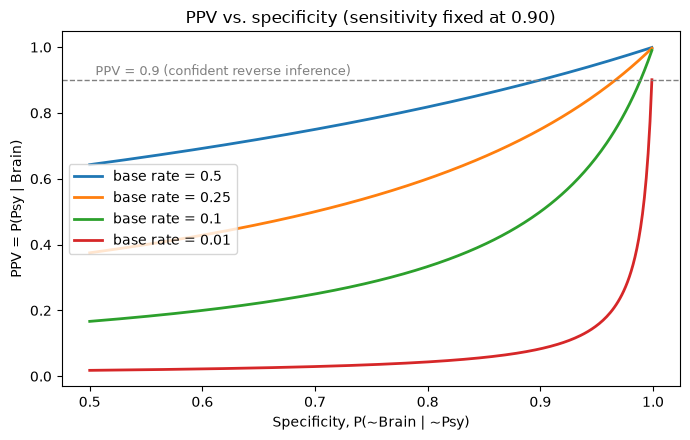

In [4]:
spec_grid = np.linspace(0.5, 0.999, 300)
base_rates = [0.5, 0.25, 0.10, 0.01]

fig, ax = plt.subplots(figsize=(7, 4.5))
for br in base_rates:
    ax.plot(spec_grid, ppv(0.90, spec_grid, br), lw=2,
            label=f"base rate = {br}")
ax.axhline(0.9, color="gray", ls="--", lw=1)
ax.text(0.505, 0.915, "PPV = 0.9 (confident reverse inference)",
        color="gray", fontsize=9)
ax.set(xlabel="Specificity, P(~Brain | ~Psy)",
       ylabel="PPV = P(Psy | Brain)",
       title="PPV vs. specificity (sensitivity fixed at 0.90)")
ax.legend(loc="center left")
plt.tight_layout()

We can also solve the PPV equation for the *required* specificity. Setting PPV = $p$ and rearranging:

$$\text{Spec}_{\text{required}} = 1 - \frac{\text{Sens} \times \text{BR} \times (1-p)}{p\,(1-\text{BR})}$$

In [5]:
def required_specificity(sens, base_rate, target_ppv):
    """Specificity needed to reach target_ppv (may exceed 1 = impossible)."""
    sens, br, p = np.asarray(sens), np.asarray(base_rate), target_ppv
    return 1 - sens * br * (1 - p) / (p * (1 - br))


br_grid = np.array([0.50, 0.25, 0.10, 0.05, 0.01, 0.001])
req = pd.DataFrame({
    "base_rate": br_grid,
    "required_spec_PPV_0.80": required_specificity(0.9, br_grid, 0.80).round(4),
    "required_spec_PPV_0.90": required_specificity(0.9, br_grid, 0.90).round(4),
    "required_spec_PPV_0.95": required_specificity(0.9, br_grid, 0.95).round(4),
})
req

,base_rate,required_spec_PPV_0.80,required_spec_PPV_0.90,required_spec_PPV_0.95
0,0.500,0.7750,0.9000,0.9526
1,0.250,0.9250,0.9667,0.9842
2,0.100,0.9750,0.9889,0.9947
3,0.050,0.9882,0.9947,0.9975
4,0.010,0.9977,0.9990,0.9995
5,0.001,0.9998,0.9999,1.0000


At a 50% base rate, ~89% specificity suffices for PPV = 0.9. At a 10% base rate you already need 99% specificity. At a 1% base rate you need ~99.9% — the region would have to activate almost *never* in the absence of the state. For rare states, no single anatomical region is plausibly that selective: this is why reverse inference from "area X lit up" fails, and why the field has turned to fine-grained multivariate patterns explicitly optimized and tested for specificity.

## 3. Base rates rule: the screening problem

The same arithmetic governs medical screening. Mammography has ~90% sensitivity and 80–99% specificity depending on setting, yet for 40–50-year-old women (10-year base rate of breast cancer ≈ 1.5%) a positive screen implies cancer with probability of only ~6% at 80% specificity — or ~40% at 98% specificity. Let's plot PPV as a function of base rate for these two specificities.

PPV at base rate 1.47%: spec 0.80 -> 0.063, spec 0.98 -> 0.402


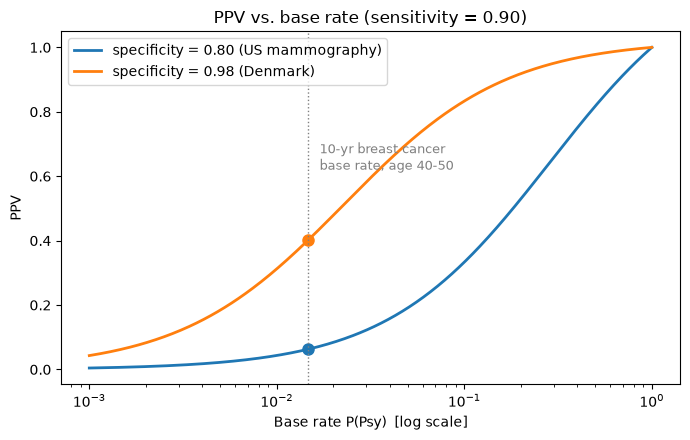

In [6]:
br_grid = np.logspace(-3, 0, 400)            # base rates from 0.1% to 100%

fig, ax = plt.subplots(figsize=(7, 4.5))
for spec, label in [(0.80, "specificity = 0.80 (US mammography)"),
                    (0.98, "specificity = 0.98 (Denmark)")]:
    ax.semilogx(br_grid, ppv(0.90, spec, br_grid), lw=2, label=label)

br_mammo = 0.0147
for spec, c in [(0.80, "C0"), (0.98, "C1")]:
    ax.plot(br_mammo, ppv(0.90, spec, br_mammo), "o", color=c, ms=8)
ax.axvline(br_mammo, color="gray", ls=":", lw=1)
ax.text(br_mammo * 1.15, 0.62, "10-yr breast cancer\nbase rate, age 40-50",
        fontsize=9, color="gray")
ax.set(xlabel="Base rate P(Psy)  [log scale]", ylabel="PPV",
       title="PPV vs. base rate (sensitivity = 0.90)")
ax.legend(loc="upper left")
plt.tight_layout()

print(f"PPV at base rate 1.47%: spec 0.80 -> {ppv(.9, .80, br_mammo):.3f}, "
      f"spec 0.98 -> {ppv(.9, .98, br_mammo):.3f}")

Both curves have high sensitivity, yet at low base rates the PPV differs by nearly an order of magnitude depending on specificity — and both are far below what the sensitivity alone suggests. Translational neuroimaging faces exactly this issue: case–control studies of depression, dementia, or chronic pain rarely assess the base rates of the disorders in the populations where a biomarker would actually be deployed.

## 4. A toy reverse-inference map (the Neurosynth idea)

Meta-analytic databases like Neurosynth make this concrete for whole brain maps. A **forward-inference map** shows $P(\text{activation} \mid \text{term})$ — how consistently a voxel activates in studies about, say, pain. A **reverse-inference (association) map** instead asks how *diagnostic* activation is of the term, accounting for how often the voxel activates across all *other* kinds of studies.

We simulate a small 2D "brain" with two active regions:

- **Region S** (selective): activates strongly for our target state, rarely otherwise.
- **Region G** (general): activates strongly for the target state *and* for many other states — like the "salience network" regions that appear in a huge fraction of all fMRI studies.

Each voxel has a sensitivity $P(\text{act} \mid \text{Psy})$ and a false-alarm rate $P(\text{act} \mid \sim\text{Psy})$. From these we compute the **likelihood ratio** $LR = \frac{P(\text{act} \mid \text{Psy})}{P(\text{act} \mid \sim\text{Psy})}$ and the posterior map $P(\text{Psy} \mid \text{act})$ at a given base rate.

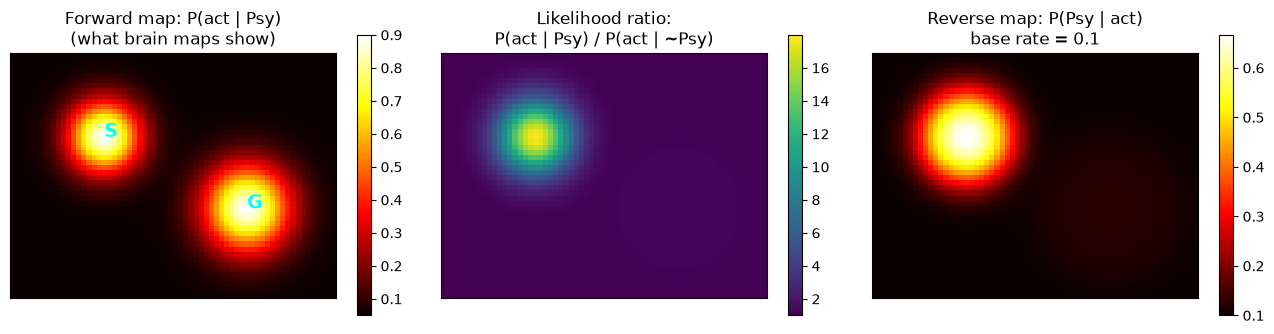

In [7]:
def gauss2d(shape, center, width):
    yy, xx = np.mgrid[0:shape[0], 0:shape[1]]
    return np.exp(-((xx - center[1]) ** 2 + (yy - center[0]) ** 2)
                  / (2 * width ** 2))

shape = (48, 64)

# P(act | Psy): BOTH regions respond strongly to the target state
sens_map = 0.05 + 0.85 * (gauss2d(shape, (16, 18), 5)      # Region S
                          + gauss2d(shape, (30, 46), 6))   # Region G
sens_map = np.clip(sens_map, 0, 0.95)

# P(act | ~Psy): only Region G also responds to many OTHER states
fa_map = 0.05 + 0.65 * gauss2d(shape, (30, 46), 6)
fa_map = np.clip(fa_map, 0, 0.90)

base_rate = 0.10
lr_map = sens_map / fa_map                                  # likelihood ratio
posterior_map = ppv(sens_map, 1 - fa_map, base_rate)        # P(Psy | act)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
for ax, img, title, cmap in [
        (axes[0], sens_map, "Forward map: P(act | Psy)\n(what brain maps show)", "hot"),
        (axes[1], lr_map, "Likelihood ratio:\nP(act | Psy) / P(act | ~Psy)", "viridis"),
        (axes[2], posterior_map, f"Reverse map: P(Psy | act)\nbase rate = {base_rate}", "hot")]:
    im = ax.imshow(img, cmap=cmap)
    ax.set(title=title, xticks=[], yticks=[])
    fig.colorbar(im, ax=ax, shrink=0.85)
axes[0].annotate("S", (18, 16), color="cyan", fontsize=14, weight="bold")
axes[0].annotate("G", (46, 30), color="cyan", fontsize=14, weight="bold")
plt.tight_layout()

In the **forward map** (left), regions S and G look almost identical — both are "reliably activated by the task," and a standard group analysis would report both. But the **likelihood ratio** and the **posterior reverse-inference map** (right) tell a different story: only the selective region S carries real evidence about the state. Region G, which responds to nearly everything, is almost uninformative — its posterior barely exceeds the base rate.

In [8]:
def summarize(name, yx):
    s, f = sens_map[yx], fa_map[yx]
    print(f"Region {name}: sens = {s:.2f}, P(act|~Psy) = {f:.2f}, "
          f"LR = {s / f:5.1f}, P(Psy|act) = {ppv(s, 1 - f, base_rate):.2f}")

summarize("S (selective)", (16, 18))
summarize("G (general)  ", (30, 46))
print(f"\nPrior P(Psy) = {base_rate:.2f}")

Region S (selective): sens = 0.90, P(act|~Psy) = 0.05, LR =  18.0, P(Psy|act) = 0.67
Region G (general)  : sens = 0.90, P(act|~Psy) = 0.70, LR =   1.3, P(Psy|act) = 0.13

Prior P(Psy) = 0.10


Activation in region S raises the probability of the state from the 10% prior to roughly 65%; activation in region G leaves it near 12%. Same forward inference, radically different reverse inference — the entire difference lies in $P(\text{act} \mid \sim\text{Psy})$, which standard brain maps never measure.

## Wrap-up

- Forward inference (sensitivity, $P(\text{Brain} \mid \text{Psy})$) is what standard brain maps deliver; reverse inference (PPV, $P(\text{Psy} \mid \text{Brain})$) is what mind-reading claims require.
- Bayes' rule shows PPV depends strongly on **specificity** and **base rate**, and only weakly on sensitivity.
- For rare states, even extremely specific regions yield weak reverse inferences — and required specificity grows out of reach as base rate falls.
- Valid reverse inference requires measuring $P(\text{act} \mid \sim\text{Psy})$ across many confusable alternatives — the logic behind Neurosynth's association maps and specificity-tested multivariate signatures.

**Next:** Chapter 8 examines which inferences from brain maps are valid and which are not.